In [6]:
import pandas as pd

In [7]:
file_path = "medical_students_dataset.csv"
df = pd.read_csv(file_path)

In [8]:
# Vis en oversigt over manglende værdier per kolonne
missing_summary = df.isnull().sum()
missing_percentage = (df.isnull().mean() * 100).round(2)
# Kombineret visning
missing_info = pd.DataFrame({
    "Missing Values": missing_summary,
    "Percentage (%)": missing_percentage
}).sort_values(by="Missing Values", ascending=False)

df_shape = df.shape

missing_info, df_shape


(                Missing Values  Percentage (%)
 Student ID               20000            10.0
 Age                      20000            10.0
 Gender                   20000            10.0
 Height                   20000            10.0
 Weight                   20000            10.0
 Blood Type               20000            10.0
 BMI                      20000            10.0
 Temperature              20000            10.0
 Heart Rate               20000            10.0
 Blood Pressure           20000            10.0
 Cholesterol              20000            10.0
 Diabetes                 20000            10.0
 Smoking                  20000            10.0,
 (200000, 13))

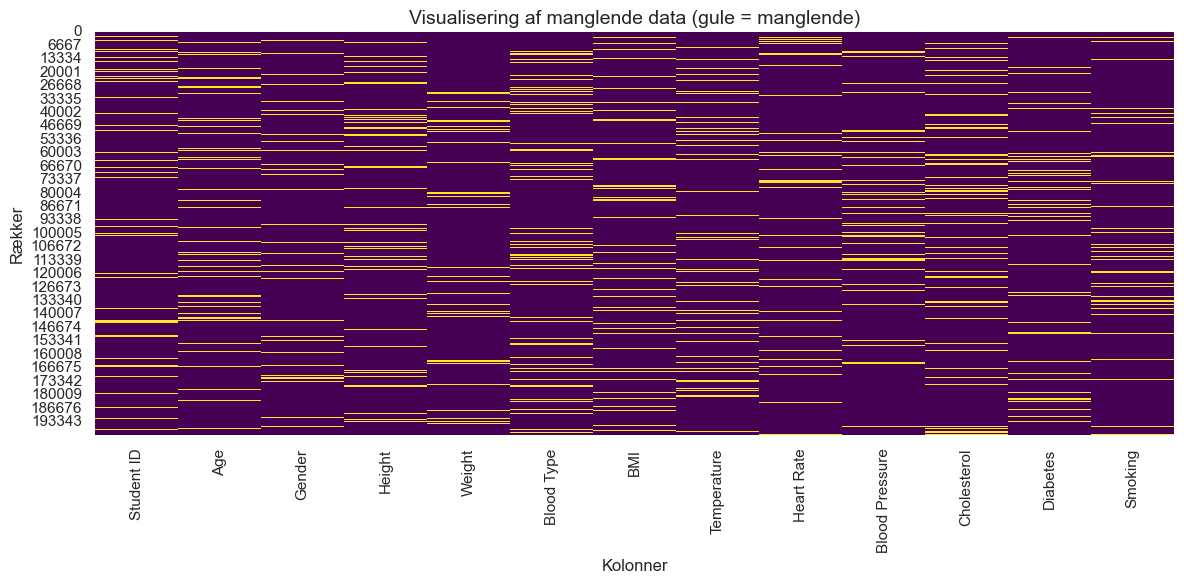

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sæt en flot stil
sns.set(style="whitegrid")

# Heatmap: hvor er data manglende?
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Visualisering af manglende data (gule = manglende)", fontsize=14)
plt.xlabel("Kolonner")
plt.ylabel("Rækker")
plt.tight_layout()
plt.show()


In [2]:
import pandas as pd
from sklearn.experimental import enable_iterative_imputer  # Aktiverer eksperimentel funktion i scikit-learn
from sklearn.impute import IterativeImputer               # Importerer regressionsbaseret imputering
from sklearn.model_selection import train_test_split      # Til at opdele datasættet i træning/test
from sklearn.preprocessing import LabelEncoder            # Til at kode kategoriske data til tal
from sklearn.ensemble import RandomForestClassifier       # Klassifikationsmodel
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score  # Evalueringsmetrikker

# 1. Indlæs datasættet fra CSV-fil
df = pd.read_csv("medical_students_dataset.csv")

# ✅ Begræns datasættet til de første 5000 rækker for at reducere køretid
df = df.head(5000)

# 2. Vælg relevante kolonner (features + target)
features = ["BMI", "Height"]   # Uafhængige variabler
target = "Diabetes"            # Det vi gerne vil forudsige

# 3. Fjern rækker hvor målet (Diabetes) mangler
df = df[features + [target]].dropna(subset=[target])

# 4. Konverter 'Yes/No' i Diabetes-kolonnen til 1/0
le = LabelEncoder()
df[target] = le.fit_transform(df[target])  # Yes → 1, No → 0

# 5. Adskil features og target i to variable
X = df[features]
y = df[target]

# 6. Udfør regressionsbaseret imputering på manglende værdier i features
reg_imputer = IterativeImputer(random_state=42)
X_imputed = reg_imputer.fit_transform(X)  # Returnerer numpy array

# 7. Del data op i trænings- og testdatasæt (80% træning, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

# 8. Træn en Random Forest-klassifikationsmodel på træningsdata
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 9. Brug modellen til at forudsige testdata
y_pred = model.predict(X_test)

# 10. Beregn og gem præstationsmål for modellen
accuracy = accuracy_score(y_test, y_pred)       # Hvor ofte forudsiger modellen korrekt
precision = precision_score(y_test, y_pred)     # Hvor mange af de positive forudsigelser er korrekte
recall = recall_score(y_test, y_pred)           # Hvor mange af de faktiske positive bliver fundet
f1 = f1_score(y_test, y_pred)                   # Harmonic mean af precision og recall

# Udskriv resultaterne
print("Modelpræstation efter regressionsbaseret imputering (5000 rækker):")
print(f"Accuracy:  {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1-score:  {f1:.2f}")


Modelpræstation efter regressionsbaseret imputering (5000 rækker):
Accuracy:  0.89
Precision: 0.20
Recall:    0.05
F1-score:  0.08


In [3]:
import pandas as pd
from sklearn.experimental import enable_iterative_imputer  # Aktiverer eksperimentel funktion i scikit-learn
from sklearn.impute import IterativeImputer               # Bruger regressionsbaseret imputering
from sklearn.model_selection import train_test_split      # Til at opdele data i trænings- og testdatasæt
from sklearn.preprocessing import LabelEncoder            # Til at konvertere kategoriske labels til tal
from sklearn.ensemble import RandomForestClassifier       # Klassifikationsmodel
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score  # Evalueringsmetrikker

# 1. Indlæs datasæt fra CSV-fil
df = pd.read_csv("medical_students_dataset.csv")

# 2. Vælg de relevante kolonner (features og target)
features = ["BMI", "Height"]   # Uafhængige variabler
target = "Diabetes"            # Det vi gerne vil forudsige (afhængig variabel)

# 3. Fjern rækker hvor målet (Diabetes) mangler
df = df[features + [target]].dropna(subset=[target])

# 4. Konverter 'Yes/No' i target-kolonnen til numeriske værdier (0 og 1)
le = LabelEncoder()
df[target] = le.fit_transform(df[target])  # Yes → 1, No → 0

# 5. Separér inputvariabler (X) og target (y)
X = df[features]
y = df[target]

# 6. Udfør regressionsimputering for at udfylde manglende værdier i X
reg_imputer = IterativeImputer(random_state=42)
X_imputed = reg_imputer.fit_transform(X)  # Returnerer et numpy array med udfyldte værdier

# 7. Opdel data i trænings- og testdatasæt (80% træning, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

# 8. Træn en Random Forest-model på træningsdata
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 9. Brug modellen til at forudsige på testdatasættet og evaluer præstation
y_pred = model.predict(X_test)

# Evalueringsmetrikker: hvor godt modellen præsterer
accuracy = accuracy_score(y_test, y_pred)       # Andelen af korrekte forudsigelser
precision = precision_score(y_test, y_pred)     # Andel af positive forudsigelser der er korrekte
recall = recall_score(y_test, y_pred)           # Andel af faktiske positive der blev fanget
f1 = f1_score(y_test, y_pred)                   # Kombination af precision og recall (harmonisk gennemsnit)

# 10. Udskriv modelens præstation
print("Model performance efter regressionsimputering:")
print(f"Accuracy:  {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1-score:  {f1:.2f}")


Model performance efter regressionsimputering:
Accuracy:  0.94
Precision: 0.75
Recall:    0.53
F1-score:  0.62


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split      # Til opdeling af datasættet
from sklearn.preprocessing import LabelEncoder            # Til at omkode 'Yes/No' til 1/0
from sklearn.ensemble import RandomForestClassifier       # Klassifikationsmodel
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score  # Evalueringsmetrikker

# 1. Indlæs hele datasættet fra CSV-fil
df = pd.read_csv("medical_students_dataset.csv")

# 2. Vælg de kolonner, vi vil arbejde med (features + target)
features = ["BMI", "Height"]   # Uafhængige variabler (input)
target = "Diabetes"            # Det vi ønsker at forudsige (målvariabel)

# 3. Fjern alle rækker der har manglende værdier i enten features eller target
df = df[features + [target]].dropna()  # Ingen imputering bruges her

# 4. Konverter 'Yes/No' i target-kolonnen til numeriske værdier (1 og 0)
le = LabelEncoder()
df[target] = le.fit_transform(df[target])  # Yes → 1, No → 0

# 5. Adskil features (X) og target (y)
X = df[features]   # Inputvariabler
y = df[target]     # Målvariabel

# 6. Del datasættet i trænings- og testdata (80% træning, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Træn en Random Forest-model på træningsdata
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 8. Brug modellen til at forudsige testdata og mål præstation
y_pred = model.predict(X_test)

# Beregn evalueringsmetrikker
accuracy = accuracy_score(y_test, y_pred)       # Hvor mange forudsigelser er korrekte
precision = precision_score(y_test, y_pred)     # Hvor mange af de positive forudsigelser er korrekte
recall = recall_score(y_test, y_pred)           # Hvor mange af de faktiske positive blev fanget
f1 = f1_score(y_test, y_pred)                   # Kombination af precision og recall

# Udskriv modelens præstation
print("Model performance uden imputering:")
print(f"Accuracy:  {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1-score:  {f1:.2f}")


Model performance uden imputering:
Accuracy:  0.95
Precision: 0.92
Recall:    0.58
F1-score:  0.71


In [1]:
import sqlite3

# Forbind til en ny databasefil
conn = sqlite3.connect("workshop_students.db")
cursor = conn.cursor()


In [2]:
# Opret STUDENTS tabel
cursor.execute("""
CREATE TABLE IF NOT EXISTS Students (
    student_id INTEGER PRIMARY KEY,
    name TEXT NOT NULL,
    age INTEGER,
    gender TEXT
)
""")

# Opret HEALTHMETRICS tabel
cursor.execute("""
CREATE TABLE IF NOT EXISTS HealthMetrics (
    record_id INTEGER PRIMARY KEY AUTOINCREMENT,
    student_id INTEGER,
    bmi REAL,
    blood_pressure INTEGER,
    cholesterol INTEGER,
    diabetes TEXT,
    FOREIGN KEY(student_id) REFERENCES Students(student_id)
)
""")

conn.commit()


In [3]:
students = [
    (1, "Emma", 24, "Female"),
    (2, "Lucas", 22, "Male"),
    (3, "Sofia", 23, "Female")
]

metrics = [
    (1, 22.3, 115, 180, "No"),
    (2, 27.8, 135, 210, "Yes"),
    (3, 25.1, 120, 195, "No")
]

cursor.executemany("INSERT INTO Students (student_id, name, age, gender) VALUES (?, ?, ?, ?)", students)

cursor.executemany("""
INSERT INTO HealthMetrics (student_id, bmi, blood_pressure, cholesterol, diabetes)
VALUES (?, ?, ?, ?, ?)
""", metrics)

conn.commit()


In [4]:
cursor.execute("""
SELECT s.name, s.age, h.bmi, h.diabetes
FROM Students s
JOIN HealthMetrics h ON s.student_id = h.student_id
WHERE h.bmi > 25
""")

for row in cursor.fetchall():
    print(row)


('Lucas', 22, 27.8, 'Yes')
('Sofia', 23, 25.1, 'No')


In [5]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS StressLevels (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    student_id INTEGER,
    stress_level INTEGER,  -- fx skala fra 1-10
    FOREIGN KEY(student_id) REFERENCES Students(student_id)
)
""")


In [6]:
stress_data = [
    (1, 3),   # Emma: lav stress
    (2, 8),   # Lucas: høj stress
    (3, 6)    # Sofia: mellem stress
]

cursor.executemany("INSERT INTO StressLevels (student_id, stress_level) VALUES (?, ?)", stress_data)
conn.commit()


In [8]:
cursor.execute("""
SELECT s.name, s.age, sl.stress_level, h.diabetes
FROM Students s
JOIN StressLevels sl ON s.student_id = sl.student_id
JOIN HealthMetrics h ON s.student_id = h.student_id
""")

for row in cursor.fetchall():
    print(row)



('Emma', 24, 3, 'No')
('Lucas', 22, 8, 'Yes')
('Sofia', 23, 6, 'No')
